In [1]:
# Standard library imports
import os
import random
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cProfile
import pstats

# Configure matplotlib
plt.style.use('../fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

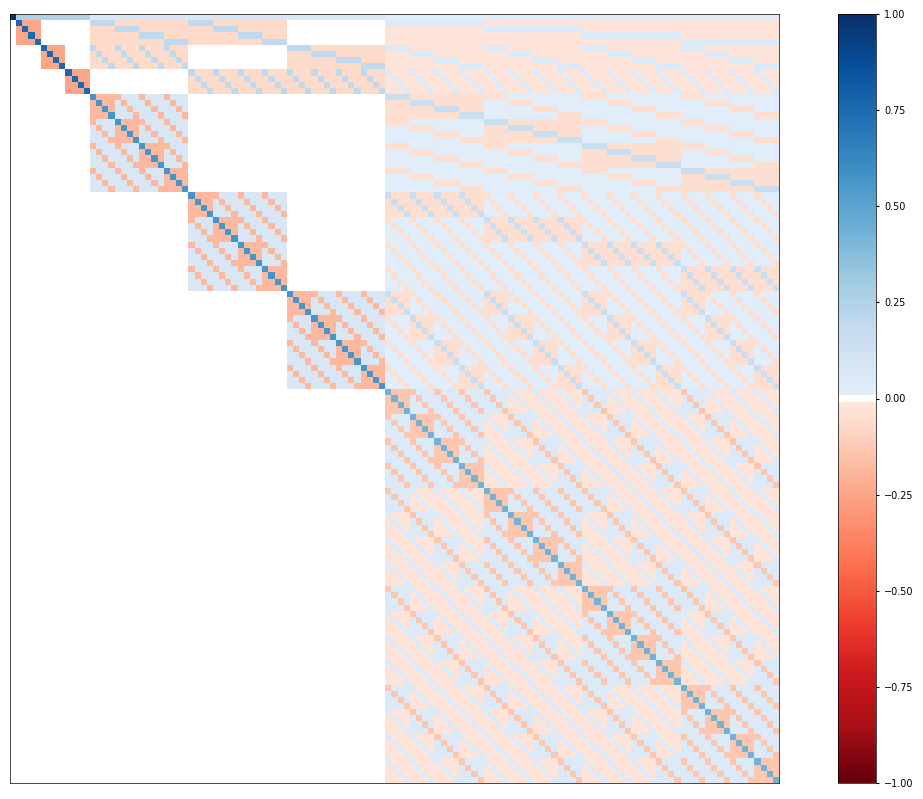

orbit              ()  (0,)                    (1,)                    (2,)  \
subseq                    A     C     G     T     A     C     G     T     A   
orbit     subseq                                                              
()                1.0  0.25  0.25  0.25  0.25  0.25  0.25  0.25  0.25  0.25   
(0,)      A       0.0  0.75 -0.25 -0.25 -0.25  0.00  0.00  0.00  0.00  0.00   
          C       0.0 -0.25  0.75 -0.25 -0.25  0.00  0.00  0.00  0.00  0.00   
          G       0.0 -0.25 -0.25  0.75 -0.25  0.00  0.00  0.00  0.00  0.00   
          T       0.0 -0.25 -0.25 -0.25  0.75  0.00  0.00  0.00  0.00  0.00   
...               ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   
(0, 1, 2) TGT     0.0 -0.00 -0.00 -0.00  0.00 -0.00 -0.00  0.00 -0.00 -0.00   
          TTA     0.0 -0.00 -0.00 -0.00  0.00 -0.00 -0.00 -0.00  0.00  0.00   
          TTC     0.0 -0.00 -0.00 -0.00  0.00 -0.00 -0.00 -0.00  0.00 -0.00   
          TTG     0.0 -0.00 -0.00 -0.00  0.00 -0.00 

In [2]:
from src.get_lambdapi_matrix import get_lambdapi_matrix
from src.visualize_matrix import visualize_matrix
from src import get_alphabet

# Set parameters
L = 3
alphabet = get_alphabet('dna')
alpha = len(alphabet)
lam = np.inf
pi_lc = np.ones((L,alpha))/alpha

# Get etapi matrix
etapi_df = get_lambdapi_matrix(L=L, alphabet=alphabet, lam=lam, pi_lc=pi_lc)

# Visualize etapi matrix
visualize_matrix(etapi_df.values, show_grid=False)

# Print etapi matrix
# Convert single index to multiindex
etapi_df.index = pd.MultiIndex.from_tuples(etapi_df.index, names=['orbit', 'subseq'])
etapi_df.columns = pd.MultiIndex.from_tuples(etapi_df.columns, names=['orbit', 'subseq'])
print(etapi_df)

In [3]:
from src import get_alphabet
from src._test_gauge_fixing import _test_gauge_fixing
from src.fix_lambdapi_series import fix_lambdapi_series
from src import get_allorder_features

L = 8
alphabet = get_alphabet('dna')
alpha = len(alphabet)
pi_lc = np.ones((L,alpha))/alpha

# Create all-order model features and corresponding embedder
features = get_allorder_features(L=L, alphabet=alphabet)
N = len(features)
print(f'{N=:,}')

# Create theta_series
theta_series = pd.Series(index=features, data=np.random.normal(size=N))

# Fix the gauge
theta_fixed_series = fix_lambdapi_series(theta_series, lam=lam, pi_lc=pi_lc, L=L, alphabet=alphabet)

# Test that the gauge-fixed series is correct
_test_gauge_fixing(theta_series, theta_fixed_series, L=L, alphabet=alphabet)

N=390,625
000 f=-5.559579 	 f_fixed=-5.559579
001 f=22.134885 	 f_fixed=22.134885
002 f=-22.310747 	 f_fixed=-22.310747
003 f=-25.387840 	 f_fixed=-25.387840
004 f=4.848235 	 f_fixed=4.848235
005 f=2.467958 	 f_fixed=2.467958
006 f=-11.149297 	 f_fixed=-11.149297
007 f=6.713918 	 f_fixed=6.713918
008 f=6.106219 	 f_fixed=6.106219
009 f=9.745142 	 f_fixed=9.745142
010 f=28.542285 	 f_fixed=28.542285
011 f=11.936933 	 f_fixed=11.936933
012 f=-23.751950 	 f_fixed=-23.751950
013 f=-24.428396 	 f_fixed=-24.428396
014 f=37.790400 	 f_fixed=37.790400
015 f=3.312585 	 f_fixed=3.312585
016 f=17.358470 	 f_fixed=17.358470
017 f=27.291490 	 f_fixed=27.291490
018 f=6.788740 	 f_fixed=6.788740
019 f=14.781624 	 f_fixed=14.781624
020 f=-19.228075 	 f_fixed=-19.228075
021 f=-1.084139 	 f_fixed=-1.084139
022 f=27.966324 	 f_fixed=27.966324
023 f=-2.967557 	 f_fixed=-2.967557
024 f=30.929798 	 f_fixed=30.929798
025 f=-6.379566 	 f_fixed=-6.379566
026 f=8.783835 	 f_fixed=8.783835
027 f=15.645699 	 f_fi

In [4]:
theta_series

((), )                                  0.013751
((0,), A)                              -0.120117
((0,), C)                              -0.209301
((0,), G)                               0.358067
((0,), T)                              -0.089741
                                          ...   
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTGT)    0.562393
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTTA)    1.613387
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTTC)   -0.952596
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTTG)   -0.221824
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTTT)    0.122248
Length: 390625, dtype: float64

In [5]:
theta_fixed_series

((), )                                  4.832862
((0,), A)                               0.093123
((0,), C)                              -0.891536
((0,), G)                               0.150135
((0,), T)                               0.648278
                                          ...   
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTGT)   -0.252722
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTTA)    0.258400
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTTC)    0.110070
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTTG)   -0.336358
((0, 1, 2, 3, 4, 5, 6, 7), TTTTTTTT)   -0.032112
Length: 390625, dtype: float64

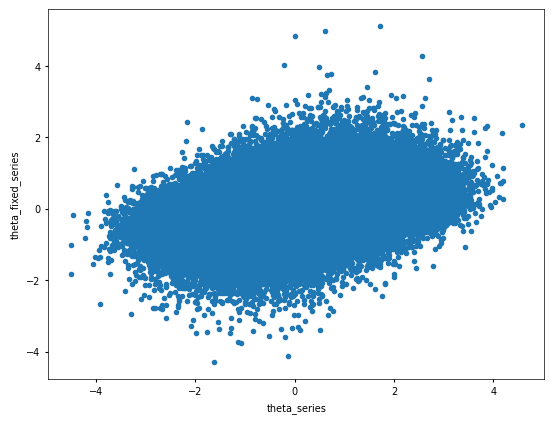

In [6]:
import matplotlib.pyplot as plt
plt.scatter(theta_series.values, theta_fixed_series.values, marker='.')
plt.xlabel('theta_series')
plt.ylabel('theta_fixed_series')
plt.show()